In [26]:
from dotenv import load_dotenv
import os

# Carrega o .env. Ajuste o caminho conforme a localização do arquivo:
load_dotenv("../.env")    # se o .env está na pasta acima (raiz do projeto NLP/)
# load_dotenv(".env")     # se o .env está na mesma pasta do notebook
# load_dotenv()           # busca automaticamente subindo diretórios

# Verifica
key = os.environ.get("DEEPSEEK_API_KEY", "")
print("Chave carregada:", bool(key), "| Tamanho:", len(key), "| Começa com:", repr(key[:6]))

Chave carregada: True | Tamanho: 35 | Começa com: 'sk-b65'


In [20]:
"""
================================================================================
 Text Clustering e Topic Modeling — Código de apoio à apresentação
 (versão com DeepSeek em vez de OpenAI / Gemini)
================================================================================

Material adaptado do Capítulo 5 de
    "Hands-On Large Language Models" (Jay Alammar & Maarten Grootendorst, 2024).

Pré-requisitos:

    pip install -U sentence-transformers umap-learn hdbscan bertopic \
                   datasets datamapplot matplotlib pandas python-dotenv

    # Para usar o DeepSeek via LiteLLM (recomendado):
    pip install "bertopic[litellm]" litellm

    # OU via SDK do OpenAI (DeepSeek é API-compatível com OpenAI):
    pip install openai

Configuração da chave de API:

    1. Crie uma conta em https://platform.deepseek.com
    2. Vá em "API Keys" e gere uma chave (começa com 'sk-')
    3. ATENÇÃO: DeepSeek é PAGO (sem tier gratuito), mas extremamente barato:
       - deepseek-chat: ~$0.27 / 1M tokens input, $1.10 / 1M tokens output
       - 154 chamadas curtas de rotulagem custam < $0.01
       - Adicione crédito mínimo em https://platform.deepseek.com/top_up
    4. Salve no .env na raiz do projeto:
       DEEPSEEK_API_KEY=sk-...

Cada bloco está numerado e corresponde a um slide da apresentação.
Recomenda-se executá-los em sequência num notebook Jupyter ou Colab.
"""

import os
from dotenv import load_dotenv

load_dotenv("../.env")  # ajuste se .env estiver em outro lugar


# =============================================================================
# Bloco 1 — Carregando os abstracts do ArXiv (cs.CL)
#           Slide 6: Etapa 1 — Gerando embeddings
# =============================================================================
from datasets import load_dataset

dataset   = load_dataset("maartengr/arxiv_nlp")["train"]
abstracts = dataset["Abstracts"]
titles    = dataset["Titles"]

print(f"Total de abstracts: {len(abstracts):,}")




Total de abstracts: 44,949


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

Forma das embeddings: (44949, 384)
Clusters detectados: 154
Documentos em outliers (cluster -1): 14,619
  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo ...

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang ...

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lo

In [ ]:
# =============================================================================
# Bloco 2 — Gerando embeddings com Sentence-Transformers
#           Slide 6
# =============================================================================
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

print("Forma das embeddings:", embeddings.shape)   # (44949, 384)




In [ ]:
# =============================================================================
# Bloco 3 — Reduzindo a dimensionalidade com UMAP
#           Slide 7
# =============================================================================
from umap import UMAP

# 5 dimensões para clusterizar
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
reduced_embeddings = umap_model.fit_transform(embeddings)

# 2 dimensões para visualizar depois
viz_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
).fit_transform(embeddings)


In [ ]:


# =============================================================================
# Bloco 4 — Clustering com HDBSCAN
#           Slide 8
# =============================================================================
from hdbscan import HDBSCAN
import numpy as np

hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    core_dist_n_jobs=1,   # evita BrokenProcessPool por descompasso numpy/joblib
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

n_clusters = len(set(clusters))
n_outliers = (clusters == -1).sum()
print(f"Clusters detectados: {n_clusters}")
print(f"Documentos em outliers (cluster -1): {n_outliers:,}")

# Inspecionando 3 documentos do cluster 0
cluster_id = 0
for idx in np.where(clusters == cluster_id)[0][:3]:
    print(abstracts[idx][:300], "...\n")




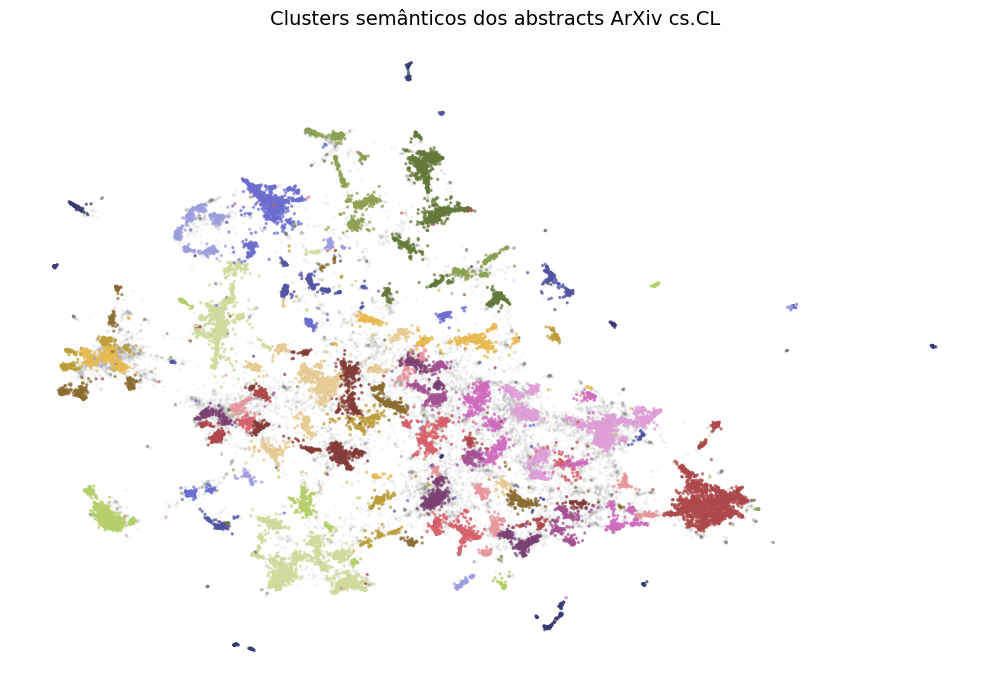

In [21]:
# =============================================================================
# Bloco 5 — Visualizando os clusters em 2D com matplotlib
#           Slide 9
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(viz_embeddings, columns=["x", "y"])
df["title"]   = titles
df["cluster"] = [str(c) for c in clusters]

to_plot  = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]

plt.figure(figsize=(10, 7))
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    to_plot.x, to_plot.y,
    c=to_plot.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b",
)
plt.axis("off")
plt.title("Clusters semânticos dos abstracts ArXiv cs.CL", fontsize=14)
plt.tight_layout()
plt.show()




In [22]:
# =============================================================================
# Bloco 6 — Treinando BERTopic
#           Slide 13
# =============================================================================
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True,
).fit(abstracts, embeddings)

# Visão geral dos tópicos
print(topic_model.get_topic_info().head(10))

# Palavras-chave de um tópico específico
print("\nTópico 0:")
for kw, score in topic_model.get_topic(0):
    print(f"  {kw:<15s} {score:.4f}")

# Buscando tópicos semelhantes a um termo
ids, scores = topic_model.find_topics("topic modeling")
print("\nTópicos similares a 'topic modeling':", list(zip(ids, scores)))


# =============================================================================
# Bloco 7 — Visualizações nativas do BERTopic
#           Slide 14
# =============================================================================
fig_docs = topic_model.visualize_documents(
    titles,
    reduced_embeddings=viz_embeddings,
    width=1200,
    hide_annotations=True,
)
fig_docs.update_layout(font=dict(size=16))
# fig_docs.show()

topic_model.visualize_barchart()
topic_model.visualize_heatmap(n_clusters=30)
topic_model.visualize_hierarchy()
topic_model.visualize_topics()




2026-05-14 16:42:09,032 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-14 16:42:31,783 - BERTopic - Dimensionality - Completed ✓
2026-05-14 16:42:31,784 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-14 16:42:33,063 - BERTopic - Cluster - Completed ✓
2026-05-14 16:42:33,069 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-14 16:42:35,533 - BERTopic - Representation - Completed ✓


   Topic  Count                                           Name  \
0     -1  14619                               -1_the_of_and_to   
1      0   2066                   0_speech_asr_recognition_end   
2      1   1428          1_medical_clinical_biomedical_patient   
3      2   1113            2_sentiment_aspect_analysis_reviews   
4      3    888  3_summarization_summaries_summary_abstractive   
5      4    837              4_hate_offensive_speech_detection   
6      5    678                 5_gender_bias_biases_debiasing   
7      6    669             6_relation_extraction_re_relations   
8      7    649              7_reasoning_cot_math_mathematical   
9      8    615               8_translation_nmt_machine_neural   

                                      Representation  \
0  [the, of, and, to, in, we, that, for, on, lang...   
1  [speech, asr, recognition, end, acoustic, audi...   
2  [medical, clinical, biomedical, patient, healt...   
3  [sentiment, aspect, analysis, reviews, opinion

In [24]:
# =============================================================================
# Bloco 8 — Refinando com KeyBERTInspired
#           Slide 15
# =============================================================================
from copy import deepcopy
from bertopic.representation import KeyBERTInspired

original_topics = deepcopy(topic_model.topic_representations_)

representation_model = KeyBERTInspired()
topic_model.update_topics(
    abstracts,
    representation_model=representation_model,
)


def topic_differences(model, original_topics, nr_topics=5):
    """Compara representações antes e depois do representation model."""
    rows = []
    for topic_id in range(nr_topics):
        og  = " | ".join([w for w, _ in original_topics[topic_id][:5]])
        new = " | ".join([w for w, _ in model.get_topic(topic_id)[:5]])
        rows.append({"Topic": topic_id, "Original": og, "Updated": new})
    return pd.DataFrame(rows)


print(topic_differences(topic_model, original_topics))




   Topic                                           Original  \
0      0  transcription | speech | phonetic | encoder | ...   
1      1         nlp | clinical | ehr | language | medicine   
2      2  sentiment | sentiments | aspect | analysis | a...   
3      3  summarization | summarizers | summaries | summ...   
4      4    hate | hateful | language | offensive | twitter   

                                             Updated  
0  transcription | speech | phonetic | encoder | ...  
1         nlp | clinical | ehr | language | medicine  
2  sentiment | sentiments | aspect | analysis | a...  
3  summarization | summarizers | summaries | summ...  
4    hate | hateful | language | offensive | twitter  


In [25]:
# =============================================================================
# Bloco 9 — Diversificando com Maximal Marginal Relevance (MMR)
#           Slide 16
# =============================================================================
from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.2)
topic_model.update_topics(
    abstracts,
    representation_model=representation_model,
)

print(topic_differences(topic_model, original_topics))




   Topic                                           Original  \
0      0  transcription | speech | phonetic | encoder | ...   
1      1         nlp | clinical | ehr | language | medicine   
2      2  sentiment | sentiments | aspect | analysis | a...   
3      3  summarization | summarizers | summaries | summ...   
4      4    hate | hateful | language | offensive | twitter   

                                             Updated  
0             speech | asr | audio | wer | automatic  
1  medical | clinical | biomedical | patient | pa...  
2  sentiment | analysis | reviews | polarity | cl...  
3  summarization | summaries | abstractive | docu...  
4       hate | offensive | toxic | abusive | hateful  


In [28]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,transcription | speech | phonetic | encoder | ...,Low-resource ASR and self-supervised learning
1,1,nlp | clinical | ehr | language | medicine,Medical NLP & Clinical Text Mining
2,2,sentiment | sentiments | aspect | analysis | a...,Aspect-based Sentiment Analysis
3,3,summarization | summarizers | summaries | summ...,Text summarization evaluation and methods
4,4,hate | hateful | language | offensive | twitter,hate speech detection in social media


In [27]:
# =============================================================================
# Bloco 10 — Usando DEEPSEEK (via LiteLLM) para gerar labels  [RECOMENDADO]
#            Slide 17
# -----------------------------------------------------------------------------
# DeepSeek é compatível com OpenAI e suportado nativamente pelo LiteLLM.
# Vantagens sobre o Gemini free tier:
#   • Sem rate limit agressivo (60 req/min vs. 5 req/min do Gemini free)
#   • Preço muito baixo: rotular 154 tópicos custa ~$0.005-$0.01
#   • Janela de contexto de 128K tokens
#
# Modelos disponíveis:
#   • deepseek/deepseek-chat       — uso geral, rápido (RECOMENDADO p/ labels)
#   • deepseek/deepseek-reasoner   — raciocínio avançado (mais lento e caro)
# =============================================================================
from bertopic.representation import LiteLLM

if "DEEPSEEK_API_KEY" not in os.environ:
    raise RuntimeError(
        "Defina DEEPSEEK_API_KEY no .env ou no ambiente. "
        "Obtenha em https://platform.deepseek.com/api_keys"
    )

prompt_deepseek = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the format:
topic: <short topic label>
"""

representation_model = LiteLLM(
    model="deepseek/deepseek-chat",   # prefixo "deepseek/" é obrigatório no LiteLLM
    prompt=prompt_deepseek,
    nr_docs=4,
    delay_in_seconds=1,               # DeepSeek aceita ~60 req/min sem problemas
)

topic_model.update_topics(
    abstracts,
    representation_model=representation_model,
)

print(topic_differences(topic_model, original_topics))




100%|██████████| 154/154 [05:07<00:00,  2.00s/it]

   Topic                                           Original  \
0      0  transcription | speech | phonetic | encoder | ...   
1      1         nlp | clinical | ehr | language | medicine   
2      2  sentiment | sentiments | aspect | analysis | a...   
3      3  summarization | summarizers | summaries | summ...   
4      4    hate | hateful | language | offensive | twitter   

                                         Updated  
0  Low-resource ASR and self-supervised learning  
1             Medical NLP & Clinical Text Mining  
2                Aspect-based Sentiment Analysis  
3      Text summarization evaluation and methods  
4          hate speech detection in social media  


In [29]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,transcription | speech | phonetic | encoder | ...,Low-resource ASR and self-supervised learning
1,1,nlp | clinical | ehr | language | medicine,Medical NLP & Clinical Text Mining
2,2,sentiment | sentiments | aspect | analysis | a...,Aspect-based Sentiment Analysis
3,3,summarization | summarizers | summaries | summ...,Text summarization evaluation and methods
4,4,hate | hateful | language | offensive | twitter,hate speech detection in social media


In [ ]:
# # =============================================================================
# # Bloco 10b — Alternativa: DEEPSEEK via SDK do OpenAI (sem LiteLLM)
# #             Slide 17
# # -----------------------------------------------------------------------------
# # DeepSeek expõe uma API 100% compatível com OpenAI. Você pode usar o cliente
# # oficial da OpenAI apontando para o endpoint do DeepSeek. Útil se você não
# # quer instalar litellm e já tem `openai` no projeto.
# # =============================================================================
# from openai import OpenAI
# from bertopic.representation import OpenAI as BERTopicOpenAI
#
# deepseek_client = OpenAI(
#     api_key=os.environ["DEEPSEEK_API_KEY"],
#     base_url="https://api.deepseek.com",   # endpoint do DeepSeek
# )
#
# representation_model_openai_style = BERTopicOpenAI(
#     deepseek_client,
#     model="deepseek-chat",
#     chat=True,
#     prompt=prompt_deepseek,
#     nr_docs=4,
#     delay_in_seconds=1,
#     exponential_backoff=True,
# )
#
# topic_model.update_topics(
#     abstracts,
#     representation_model=representation_model_openai_style,
# )
#
# print(topic_differences(topic_model, original_topics))
#
#


In [ ]:
# # =============================================================================
# # Bloco 10c — DEEPSEEK direto, com JSON estruturado (label + descrição)
# #             Slide 17
# # -----------------------------------------------------------------------------
# # Esta abordagem NÃO usa um representation model — chama o DeepSeek diretamente
# # para cada tópico, com saída JSON estruturada. Útil para gerar tanto um label
# # curto quanto uma descrição mais longa.
# #
# # Rotular apenas os top-N tópicos é eficiente para apresentações.
# # =============================================================================
# import json
# import time
#
# # Rotula apenas os 20 tópicos com mais documentos
# top_topics = topic_model.get_topic_info().head(21).Topic.tolist()
# top_topics = [t for t in top_topics if t != -1][:20]
#
# prompt_template = """\
# You are an expert at labeling clusters of scientific abstracts.
#
# I have a topic described by these keywords:
# {keywords}
#
# Some representative documents from this topic:
# {documents}
#
# Return a JSON object with two fields:
#   - "topic_label":  a concise label (max 8 words)
#   - "description":  one sentence describing the topic
# """
#
# deepseek_labels = {}
# for tid in top_topics:
#     info = topic_model.get_topic_info()
#     row = info[info.Topic == tid].iloc[0]
#     keywords = ", ".join(w for w, _ in topic_model.get_topic(tid))
#     docs = "\n---\n".join(row.Representative_Docs[:3])
#
#     resp = deepseek_client.chat.completions.create(
#         model="deepseek-chat",
#         messages=[{
#             "role": "user",
#             "content": prompt_template.format(keywords=keywords, documents=docs),
#         }],
#         response_format={"type": "json_object"},   # força saída JSON válida
#         temperature=0.0,
#     )
#     deepseek_labels[tid] = json.loads(resp.choices[0].message.content)
#     print(f"Tópico {tid}: {deepseek_labels[tid]['topic_label']}")
#     print(f"  → {deepseek_labels[tid]['description']}\n")
#     time.sleep(1)
#
#


In [ ]:
# # =============================================================================
# # Bloco 11 — Alternativa local sem API externa: Flan-T5
# #            Slide 17 (variação offline)
# # -----------------------------------------------------------------------------
# # Mantida para referência. Em versões recentes do transformers, a task
# # 'text2text-generation' foi consolidada — use chamada direta ao modelo.
# # =============================================================================
# from transformers import T5Tokenizer, T5ForConditionalGeneration
# from bertopic.representation import TextGeneration
#
# tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-small")
# flan_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small")
#
#
# class FlanT5Wrapper:
#     """Adaptador para o TextGeneration do BERTopic."""
#     def __call__(self, prompt, **kwargs):
#         inputs = tokenizer(prompt, return_tensors="pt",
#                            truncation=True, max_length=512)
#         outputs = flan_model.generate(**inputs, max_new_tokens=50)
#         text = tokenizer.decode(outputs[0], skip_special_tokens=True)
#         return [{"generated_text": text}]
#
#
# prompt_t5 = """I have a topic that contains the following documents:
# [DOCUMENTS]
# The topic is described by the following keywords: '[KEYWORDS]'.
# Based on the documents and keywords, what is this topic about?"""
#
# representation_model = TextGeneration(
#     FlanT5Wrapper(),
#     prompt=prompt_t5,
#     doc_length=50,
#     tokenizer="whitespace",
# )
# topic_model.update_topics(
#     abstracts,
#     representation_model=representation_model,
# )
#
#


In [ ]:
# =============================================================================
# Bloco 12 — Mapa publicável com datamapplot
#            Slide 14 (extra)
# =============================================================================
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=viz_embeddings,
    width=1200,
    label_font_size=11,
    label_wrap_width=20,
    use_medoids=True,
)
# fig.savefig("topic_map.png", dpi=200)


# =============================================================================
# FIM — Próximos passos: explore as variantes algorítmicas do BERTopic
# (guided, semi-supervised, hierarchical, dynamic, multimodal, online, zero-shot)
# =============================================================================